In [1072]:
import pandas as pd
from sklearn.linear_model import LinearRegression


##### Reading training dataset

In [1073]:
df = pd.read_csv('train.csv')
df.head(20)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


# i. analyzing the features

In [1074]:
df.columns    #printing all the features/columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [1075]:
df.info()     #Basic overview

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [1076]:
df.drop(columns=['Id']).describe()     #Statistical analysis

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [1077]:
#For categorical features:
df.describe(include='object')

C:\Users\nkuma\AppData\Local\Temp\ipykernel_17248\1942688742.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


In [1078]:
#Check data types:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

In [1079]:
#Check missing values:
df.drop(columns=['Id']).isnull().sum()

MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 80, dtype: int64

In [1080]:
(df.drop(columns=['Id']).isnull().sum() / len(df)) * 100

MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
Street            0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 80, dtype: float64

Check unique values

In [1081]:
#For a particular feature:
df['LotFrontage'].unique()

array([ 65.,  80.,  68.,  60.,  84.,  85.,  75.,  nan,  51.,  50.,  70.,
        91.,  72.,  66., 101.,  57.,  44., 110.,  98.,  47., 108., 112.,
        74., 115.,  61.,  48.,  33.,  52., 100.,  24.,  89.,  63.,  76.,
        81.,  95.,  69.,  21.,  32.,  78., 121., 122.,  40., 105.,  73.,
        77.,  64.,  94.,  34.,  90.,  55.,  88.,  82.,  71., 120., 107.,
        92., 134.,  62.,  86., 141.,  97.,  54.,  41.,  79., 174.,  99.,
        67.,  83.,  43., 103.,  93.,  30., 129., 140.,  35.,  37., 118.,
        87., 116., 150., 111.,  49.,  96.,  59.,  36.,  56., 102.,  58.,
        38., 109., 130.,  53., 137.,  45., 106., 104.,  42.,  39., 144.,
       114., 128., 149., 313., 168., 182., 138., 160., 152., 124., 153.,
        46.])

In [1082]:
#Number of unique values:
df['LotFrontage'].nunique()

110

In [1083]:
#For every feature:
df.drop(columns=['Id']).nunique()

MSSubClass         15
MSZoning            5
LotFrontage       110
LotArea          1073
Street              2
                 ... 
MoSold             12
YrSold              5
SaleType            9
SaleCondition       6
SalePrice         663
Length: 80, dtype: int64

In [1084]:
#Analyze categorical features
df['Fence'].value_counts()

Fence
MnPrv    157
GdPrv     59
GdWo      54
MnWw      11
Name: count, dtype: int64

In [1085]:
#Analyze relationships between numerical features
# (correlation: +1->strong +ve relatio//-1->strong -ve relation//0->little/no linear relation):
df.drop(columns=['Id']).corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

Check duplicate rows

In [1086]:
df.duplicated().sum()

np.int64(0)

In [1087]:
#to remove duplicates
df.drop_duplicates(inplace=True)

# ii.

Estimating the missing values

In [1088]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].mean())
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


stratified k-fold cross validation

In [1089]:
X = df.drop('SalePrice', axis='columns')
X

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal


In [1090]:
y = df.SalePrice
y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [1091]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=10, shuffle=True, random_state=42)

train_index, test_index = next(kf.split(X))

X_train = X.iloc[train_index]
X_test = X.iloc[test_index]

y_train = y.iloc[train_index]
y_test = y.iloc[test_index]


# iii.

In [1092]:
model = LinearRegression()
model.fit(X[['LotArea']],y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.1]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['LotArea']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.588e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [1093]:
model.coef_

array([2.09997195])

In [1094]:
model.intercept_

np.float64(158836.1518968766)

# iv.

In [1095]:
model1 = LinearRegression()
model1.fit(X_train[['LotFrontage','LotArea']],y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[932.33, 1.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['LotFrontage','LotArea']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.007e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [1096]:
model1.coef_

array([932.33088348,   1.39778513])

In [1097]:
model2 = LinearRegression()
model2.fit(X_train[['LotFrontage','LotArea','OverallQual','OverallCond']], y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 360.46, 1.18,42218.59, -421.53]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['LotFrontage','LotArea','OverallQual','OverallCond']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.125e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [1098]:
model2.coef_

array([ 3.60455024e+02,  1.17992923e+00,  4.22185922e+04, -4.21526109e+02])

In [1099]:
model3 = LinearRegression()
model3.fit(X_train[['LotFrontage','LotArea','OverallQual','OverallCond','1stFlrSF','GrLivArea']], y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 31.56, 0.66,31050.53, 1013.57, 33.78, 38.42]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['LotFrontage','LotArea','OverallQual','OverallCond','1stFlrSF', 'GrLivArea']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.215e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [1100]:
model3.coef_

array([3.15640274e+01, 6.61026524e-01, 3.10505339e+04, 1.01357070e+03,
       3.37753207e+01, 3.84159875e+01])

# v.

In [1101]:
model1_pred = model1.predict(X_test[['LotFrontage','LotArea']])
model1_pred

array([156851.04007412, 165527.16619279, 178917.08280221, 177116.28472973,
       173103.21081361, 157951.10517368, 166751.62597012, 185011.02436107,
       182782.92206098, 208400.31879101, 177903.68858011, 182940.87178112,
       185405.20796799, 136961.81601785, 163057.23886538, 189746.73679314,
       170075.57541691, 196696.57367395, 196918.88710345, 176750.04862633,
       194237.93521657, 172260.82999443, 187946.7747674 , 181373.96284513,
       284132.96508033, 178469.79155935, 183765.54861184, 194058.95312622,
       183226.05274504, 162179.42980127, 258024.85557763, 206565.01871101,
       195437.18566658, 194889.24569493, 173425.18501099, 122674.94757498,
       172811.06552146, 187324.38335518, 170852.72755307, 169221.51230177,
       242414.06323585, 165482.4042719 , 181246.76439795, 180704.43196513,
       224382.63500814, 184548.36568089, 237965.15912908, 209131.40141182,
       183252.60246344, 168470.90168485, 169782.55695197, 155449.05338564,
       154353.18984064, 1

In [1102]:
model2_pred = model2.predict(X_test[['LotFrontage','LotArea','OverallQual','OverallCond']])
model2_pred

array([205272.20417154,  82944.28068678, 132178.90731052, 130680.08837769,
       128577.21653729, 164398.71076075, 125774.96474761, 261862.28463501,
       219469.11637357, 230861.32451183,  88683.34034543,  92946.67189238,
       177331.28258124, 154780.4594418 , 167850.84503635, 222788.17716752,
       213007.95745736, 183033.79428909, 137168.82256979, 216082.77289998,
       177967.36267994, 169200.20257125, 222973.85615437, 217853.18993159,
       303731.94446334, 216660.04038811, 136714.53785085, 266087.504367  ,
       132856.6863007 , 208485.38942069, 127321.82192913, 229317.10909352,
       224179.20688057, 266361.82455714, 212401.6757843 , 147001.07548766,
       214037.40564364, 220316.80203124, 129658.40322805, 129967.53024958,
       173425.27539383, 126831.34621116, 217745.81637134, 173799.8016741 ,
       158204.18828131,  91749.27552877, 199091.41956762, 187548.5725758 ,
       260804.49143382, 128069.32992338, 124468.06976941, 120078.10860184,
       161793.16235355, 1

In [1103]:
model3_pred = model3.predict(X_test[['LotFrontage','LotArea','OverallQual','OverallCond','1stFlrSF','GrLivArea']])
model3_pred

array([171267.92420663,  52396.20985804, 115841.04001933, 130314.43218072,
       116990.2532865 , 149387.62190353, 103809.11381229, 274317.82114249,
       217013.98986317, 274437.69168711,  86335.51090924, 144800.37225191,
       177920.87222693, 153711.0644334 , 163380.27465963, 236259.96361032,
       202773.827401  , 238676.26567917, 129391.35381404, 212333.17924832,
       194442.88993778, 136232.97716834, 231004.98332365, 217309.96931813,
       305129.37822873, 231332.73700594, 113098.09406394, 253186.56782294,
       107649.408894  , 201107.50068961,  87211.96525433, 243847.16040506,
       267825.26773012, 259296.94207514, 211509.88761088, 128914.19406326,
       211066.38695229, 210273.89120491, 112972.76631802, 121350.11272722,
       141114.5126661 , 121736.1381195 , 205843.58921016, 155897.42275341,
       127678.26154635,  82370.7037779 , 183480.88492025, 173086.51341988,
       227916.48401277, 121364.77517239, 114705.82981576, 111223.30934528,
       174615.15383282, 1

In [1104]:
from sklearn.metrics import mean_squared_error

mse1 = mean_squared_error(y_test,model1_pred)
mse2 = mean_squared_error(y_test,model2_pred)
mse3 = mean_squared_error(y_test,model3_pred)

In [1105]:
from sklearn.metrics import r2_score

model1_r2 = r2_score(y_test,model1_pred)
model2_r2 = r2_score(y_test,model2_pred)
model3_r2 = r2_score(y_test,model3_pred)

In [1106]:
print("                                              model1                                model2                          model3")
print("Mean Squared Error     ",mse1,"         ",mse2,"       ",mse3)
print("R2 score                       ",model1_r2,"      ",model2_r2,"         ",model3_r2)

                                              model1                                model2                          model3
Mean Squared Error      7630623873.467902           2939690920.0786586         2111844330.3065245
R2 score                        0.164832582035763        0.6782525104046025           0.7688598460976243


# vi.

For Model 4

In [1107]:
dummies1 = pd.get_dummies(X_train.Street).astype(int)
dummies1.head()

,Grvl,Pave
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [1108]:
merged1 = pd.concat([X_train.LotArea,dummies1],axis='columns')
merged1

,LotArea,Grvl,Pave
0,8450,0,1
1,9600,0,1
2,11250,0,1
3,9550,0,1
4,14260,0,1
...,...,...,...
1455,7917,0,1
1456,13175,0,1
1457,9042,0,1
1458,9717,0,1


In [1109]:
final1 = merged1.drop(['Grvl'],axis='columns')
final1

,LotArea,Pave
0,8450,1
1,9600,1
2,11250,1
3,9550,1
4,14260,1
...,...,...
1455,7917,1
1456,13175,1
1457,9042,1
1458,9717,1


In [1110]:
model4 = LinearRegression()
model4.fit(final1,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 2.13,116005.9 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['LotArea','Pave']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.251e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [1111]:
model4.coef_

array([2.13085871e+00, 1.16005904e+05])

For Model 5

In [1112]:
dummies2 = pd.get_dummies(X_train.Neighborhood).astype(int)
dummies2

,Blmngtn,Blueste,BrDale,BrkSide,ClearCr,CollgCr,Crawfor,Edwards,Gilbert,IDOTRR,...,NoRidge,NridgHt,OldTown,SWISU,Sawyer,SawyerW,Somerst,StoneBr,Timber,Veenker
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1456,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1457,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1458,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [1113]:
merged2 = pd.concat([dummies2,final1],axis='columns')
merged2

,Blmngtn,Blueste,BrDale,BrkSide,ClearCr,CollgCr,Crawfor,Edwards,Gilbert,IDOTRR,...,OldTown,SWISU,Sawyer,SawyerW,Somerst,StoneBr,Timber,Veenker,LotArea,Pave
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,8450,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,9600,1
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,11250,1
3,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,9550,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,14260,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,7917,1
1456,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,13175,1
1457,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,9042,1
1458,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,9717,1


In [1114]:
final2 = merged2.drop(['Veenker'],axis='columns')
final2

,Blmngtn,Blueste,BrDale,BrkSide,ClearCr,CollgCr,Crawfor,Edwards,Gilbert,IDOTRR,...,NridgHt,OldTown,SWISU,Sawyer,SawyerW,Somerst,StoneBr,Timber,LotArea,Pave
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,8450,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,9600,1
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,11250,1
3,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,9550,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,14260,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,7917,1
1456,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,13175,1
1457,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,9042,1
1458,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,9717,1


In [1115]:
model5 = LinearRegression()
model5.fit(final2,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](26,)","[ -29497.43, -84113.33,-118305.98,..., -21069.71, 1.55, 70855.66]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](26,)","['Blmngtn','Blueste','BrDale',...,'Timber','LotArea','Pave']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.482e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,26
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(26)


In [1116]:
model5.coef_

array([-2.94974283e+04, -8.41133260e+04, -1.18305977e+05, -1.06818785e+05,
       -5.56560100e+04, -3.35900562e+04, -2.87104107e+04, -1.06954694e+05,
       -4.14606673e+04, -1.23720993e+05, -1.22739881e+05, -7.79706148e+04,
       -8.81630119e+04, -8.20757164e+04, -4.82832359e+04,  8.05976553e+04,
        7.63093886e+04, -1.02263559e+05, -8.90704689e+04, -9.86596497e+04,
       -4.91035551e+04, -5.63620826e+03,  7.60425961e+04, -2.10697062e+04,
        1.55370023e+00,  7.08556604e+04])

For Model 6

In [1117]:
final3 = pd.concat([final2,X_train[['1stFlrSF','YearBuilt']]],axis='columns')
final3

,Blmngtn,Blueste,BrDale,BrkSide,ClearCr,CollgCr,Crawfor,Edwards,Gilbert,IDOTRR,...,SWISU,Sawyer,SawyerW,Somerst,StoneBr,Timber,LotArea,Pave,1stFlrSF,YearBuilt
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,8450,1,856,2003
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,9600,1,1262,1976
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,11250,1,920,2001
3,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,9550,1,961,1915
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,14260,1,1145,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,7917,1,953,1999
1456,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,13175,1,2073,1978
1457,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,9042,1,1188,1941
1458,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,9717,1,1078,1950


In [1118]:
model6 = LinearRegression()
model6.fit(final3,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](28,)","[-51042.34,-36277.61,-61991.17,..., 61622.66, 70.7 , 579.46]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](28,)","['Blmngtn','Blueste','BrDale',...,'Pave','1stFlrSF','YearBuilt']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.082e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,28
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(28)


In [1119]:
model6.coef_

array([-5.10423410e+04, -3.62776129e+04, -6.19911719e+04, -4.79572389e+04,
       -2.64130813e+04, -2.96926597e+04,  2.92834786e+03, -7.16481006e+04,
       -1.98835736e+04, -5.60686841e+04, -7.77065496e+04, -6.56358963e+04,
       -6.19087148e+04, -5.14759386e+04, -4.12150487e+04,  6.49748486e+04,
        4.88871174e+04, -4.03207440e+04, -3.36664396e+04, -6.86475751e+04,
       -4.02583586e+04, -3.78314755e+03,  5.45695857e+04, -1.94423024e+04,
        9.59625967e-01,  6.16226586e+04,  7.06970872e+01,  5.79459568e+02])

# vii.

In [1120]:
import matplotlib.pyplot as plt

In [1121]:
coef_model1 = pd.Series(model1.coef_, index=X_train[['LotFrontage','LotArea']].columns)
coef_model2 = pd.Series(model2.coef_, index=X_train[['LotFrontage','LotArea','OverallQual','OverallCond']].columns)
coef_model3 = pd.Series(model3.coef_, index=X_train[['LotFrontage','LotArea','OverallQual','OverallCond','1stFlrSF','GrLivArea']].columns)
coef_model4 = pd.Series(model4.coef_, index=final1.columns)
coef_model5 = pd.Series(model5.coef_, index=final2.columns)
coef_model6 = pd.Series(model6.coef_, index=final3.columns)

In [1122]:
print(coef_model1['LotArea'])
print(coef_model2['LotArea'])
print(coef_model3['LotArea'])
print(coef_model4['LotArea'])
print(coef_model5['LotArea'])
print(coef_model6['LotArea'])

1.3977851339310285
1.179929233528565
0.6610265242423985
2.1308587063379445
1.5537002264248565
0.9596259674944685


In [1123]:
coefficients = [
    coef_model1['LotArea'],
    coef_model2['LotArea'],
    coef_model3['LotArea'],
    coef_model4['LotArea'],
    coef_model5['LotArea'],
    coef_model6['LotArea'],
]

In [1124]:
models = ['Model 1', 'Model 2','Model 3', 'Model 4','Model 5', 'Model 6']

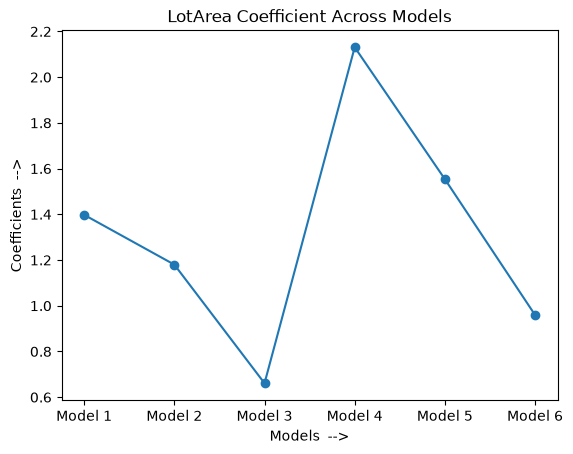

In [1125]:
plt.plot(models, coefficients, marker='o')
plt.xlabel('Models  -->')
plt.ylabel('Coefficients  -->')
plt.title('LotArea Coefficient Across Models')
plt.show()

we can also use this type of method for accessing coefficient of a specific feature

In [1126]:
coef_model1 = pd.DataFrame({
    "Feature": X_train[['LotFrontage','LotArea']].columns,
    "Coefficient": model1.coef_.ravel()
})
coef_model1

,Feature,Coefficient
0,LotFrontage,932.330883
1,LotArea,1.397785


# viii.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3)

In [1128]:
X_LotArea_train_trans = poly.fit_transform(X_train[['LotArea']])
X_test_sorted = X_test.sort_values('LotArea')
X_LotArea_test_trans = poly.transform(X_test_sorted[['LotArea']])

In [1129]:
poly_model = LinearRegression()
poly_model.fit(X_LotArea_train_trans,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0., 0., 0.,-0.]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.753e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[1.17e+16,1.21e+10,1.12e+05,0.00e+00]"


In [1130]:
poly_model.coef_

array([ 0.00000000e+00,  6.23833930e-10,  3.91359988e-05, -1.79053612e-10])

In [1131]:
lotArea = poly.get_feature_names_out(['LotArea'])

In [1132]:
coef_poly_model = pd.Series(poly_model.coef_,index=lotArea)
coef_poly_model

1            0.000000e+00
LotArea      6.238339e-10
LotArea^2    3.913600e-05
LotArea^3   -1.790536e-10
dtype: float64

In [1133]:
y_poly_pred = poly_model.predict(X_LotArea_test_trans)

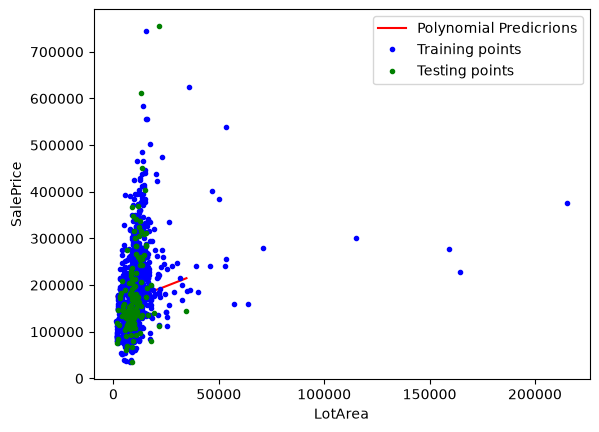

In [1134]:
plt.plot(X_test_sorted.LotArea,y_poly_pred, "-r", label="Polynomial Predicrions")
plt.plot(X_train.LotArea,y_train, "b.", label="Training points")
plt.plot(X_test.LotArea,y_test, "g.", label="Testing points")
plt.xlabel("LotArea")
plt.ylabel("SalePrice")
plt.legend()
plt.show()